# Hometask 3 — Training Neural Networks: Gradient Problems & Transfer Learning

**Goals.**
1. Reproduce the *vanishing* and *exploding* gradient problems and show how modern training tricks fix them.
2. Apply **Transfer Learning** in three modes (from scratch / feature extraction / fine-tuning) on the project's football player dataset, and compare them.

**Structure.**
- Part 1 — Gradient problems on a deep MLP (Fashion-MNIST): diagnose, then apply Xavier/He init, ReLU, BatchNorm, gradient clipping, and residual connections.
- Part 2 — Transfer Learning on the player-team dataset (ResNet-18).
- Part 3 — Summary table and take-aways.


## 1. Setup

Install any missing deps, then import everything used below. The project already has torch/torchvision/pytorch-lightning/torchmetrics from hometask 2, so this cell is mostly a no-op on a warm environment.


In [1]:
import importlib.util
import subprocess
import sys


def _pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *args])


NORMAL = [
    ('numpy',             'numpy'),
    ('matplotlib',        'matplotlib'),
    ('pandas',            'pandas'),
    ('torch',             'torch'),
    ('torchvision',       'torchvision'),
    ('pytorch-lightning', 'pytorch_lightning'),
    ('torchmetrics',      'torchmetrics'),
    ('opencv-python',     'cv2'),
]
missing = [pkg for pkg, mod in NORMAL if importlib.util.find_spec(mod) is None]
if missing:
    print(f'Installing: {missing}')
    _pip(*missing)
print('Setup complete.')


Setup complete.


In [2]:
import json
import random
from collections import Counter
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import datasets, transforms as T
from torchvision.models import resnet18, ResNet18_Weights

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch={torch.__version__}  device={DEVICE}  lightning={pl.__version__}')


torch=2.7.1+cu118  device=cuda  lightning=2.6.1


## Part 1 — Vanishing & Exploding Gradients

### 1.1 The problem, in one paragraph

During backpropagation, the gradient of an early layer is a product of many Jacobians. If those Jacobians all have norm < 1, the gradient *vanishes* exponentially with depth — the early layers stop learning. If they all have norm > 1, the gradient *explodes* — weights diverge to NaN. Classical activations (sigmoid, tanh) saturate to near-zero derivatives, which makes vanishing the default outcome in deep MLPs.

### 1.2 Experimental setup

We train a 12-layer fully-connected network on Fashion-MNIST for a few epochs. For each configuration we record:
- **per-layer gradient L2 norm** averaged across a training step,
- **training loss curve**,
- **final test accuracy**.

Depth is fixed at 12 and width at 128 — deep and narrow, which makes gradient problems visible without needing a GPU-heavy model.


In [3]:
FMNIST_ROOT = Path('./fashion_mnist')
FMNIST_TF = T.Compose([T.ToTensor(), T.Normalize((0.2860,), (0.3530,))])
fmnist_train = datasets.FashionMNIST(FMNIST_ROOT, train=True, download=True, transform=FMNIST_TF)
fmnist_test  = datasets.FashionMNIST(FMNIST_ROOT, train=False, download=True, transform=FMNIST_TF)

# Smaller training subset keeps per-config runtime low; still enough to show gradient behaviour.
rng = np.random.default_rng(SEED)
subset_idx = rng.choice(len(fmnist_train), size=10000, replace=False)
fmnist_train_small = torch.utils.data.Subset(fmnist_train, subset_idx.tolist())

FM_TRAIN = DataLoader(fmnist_train_small, batch_size=128, shuffle=True,  num_workers=0)
FM_TEST  = DataLoader(fmnist_test,        batch_size=512, shuffle=False, num_workers=0)
print(f'Fashion-MNIST  train={len(fmnist_train_small)}  test={len(fmnist_test)}')


100%|██████████| 26.4M/26.4M [00:11<00:00, 2.23MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 868kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 2.02MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Fashion-MNIST  train=10000  test=10000


In [4]:
class DeepMLP(nn.Module):
    """Deep MLP whose init / activation / normalization / residuals are configurable."""
    def __init__(self, depth=12, width=128, activation='sigmoid',
                 init='default', use_bn=False, use_residual=False,
                 num_classes=10, in_dim=28 * 28):
        super().__init__()
        self.depth = depth
        self.use_bn = use_bn
        self.use_residual = use_residual
        self.linears = nn.ModuleList()
        self.linears.append(nn.Linear(in_dim, width))
        for _ in range(depth - 1):
            self.linears.append(nn.Linear(width, width))
        self.bns = nn.ModuleList([nn.BatchNorm1d(width) for _ in range(depth)]) if use_bn else None
        self.head = nn.Linear(width, num_classes)
        self.activation = activation
        self._apply_init(init)

    def _apply_init(self, init):
        for layer in self.linears:
            if init == 'xavier':
                nn.init.xavier_uniform_(layer.weight)
            elif init == 'he':
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            elif init == 'exploding':
                nn.init.normal_(layer.weight, mean=0.0, std=1.0)  # way too large
            elif init == 'vanishing':
                nn.init.normal_(layer.weight, mean=0.0, std=0.01)  # way too small for sigmoid
            # 'default' leaves torch's defaults alone
            nn.init.zeros_(layer.bias)

    def _act(self, x):
        if self.activation == 'sigmoid':    return torch.sigmoid(x)
        if self.activation == 'tanh':       return torch.tanh(x)
        if self.activation == 'relu':       return F.relu(x)
        if self.activation == 'leaky_relu': return F.leaky_relu(x, negative_slope=0.1)
        raise ValueError(self.activation)

    def forward(self, x):
        x = x.flatten(1)
        for i, layer in enumerate(self.linears):
            y = layer(x)
            if self.bns is not None:
                y = self.bns[i](y)
            y = self._act(y)
            if self.use_residual and i > 0 and x.shape == y.shape:
                x = x + y
            else:
                x = y
        return self.head(x)


In [5]:
def run_config(name, *, epochs=3, clip=None, lr=1e-2, **model_kwargs):
    """Train one DeepMLP config and return loss curve + per-layer grad norms + test acc."""
    torch.manual_seed(SEED)
    model = DeepMLP(**model_kwargs).to(DEVICE)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    loss_hist = []
    # grad_hist[epoch][layer_idx] = mean grad L2 norm for that layer across the epoch
    grad_hist = []
    diverged = False

    for ep in range(epochs):
        model.train()
        per_layer = [[] for _ in model.linears]
        epoch_loss = 0.0
        n_batches = 0
        for xb, yb in FM_TRAIN:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            if not torch.isfinite(loss):
                diverged = True
                break
            loss.backward()
            for i, layer in enumerate(model.linears):
                g = layer.weight.grad
                per_layer[i].append(float(g.norm().item()) if g is not None else 0.0)
            if clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            epoch_loss += float(loss.item())
            n_batches += 1
        if diverged:
            break
        loss_hist.append(epoch_loss / max(n_batches, 1))
        grad_hist.append([float(np.mean(g)) if g else 0.0 for g in per_layer])

    if diverged:
        return {'name': name, 'diverged': True, 'loss': loss_hist,
                'grads': grad_hist, 'test_acc': 0.0}

    # Test accuracy
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in FM_TEST:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb).argmax(1)
            correct += int((pred == yb).sum().item())
            total += yb.numel()
    return {'name': name, 'diverged': False, 'loss': loss_hist,
            'grads': grad_hist, 'test_acc': correct / total}


### 1.3 Run the configurations

Seven configurations, chosen to isolate one intervention at a time:

| # | name                 | purpose |
|---|----------------------|---------|
| 1 | `sigmoid_default`    | Default baseline — shows natural vanishing with sigmoid + torch defaults. |
| 2 | `sigmoid_exploding`  | Same arch, but weights are init'd with std=1.0 → gradients explode. |
| 3 | `sigmoid_xavier`     | Xavier init is the classic fix for sigmoid/tanh. |
| 4 | `relu_he`            | ReLU + He init — the modern default. |
| 5 | `relu_he_bn`         | Add BatchNorm after every linear. |
| 6 | `relu_he_clip`       | Gradient clipping at 1.0 — the standard fix for explosion. |
| 7 | `relu_he_residual`   | Add identity skip connections (residual MLP). |


In [6]:
configs = [
    dict(name='sigmoid_default',   activation='sigmoid', init='default',    use_bn=False, use_residual=False),
    dict(name='sigmoid_exploding', activation='sigmoid', init='exploding',  use_bn=False, use_residual=False),
    dict(name='sigmoid_xavier',    activation='sigmoid', init='xavier',     use_bn=False, use_residual=False),
    dict(name='relu_he',           activation='relu',    init='he',         use_bn=False, use_residual=False),
    dict(name='relu_he_bn',        activation='relu',    init='he',         use_bn=True,  use_residual=False),
    dict(name='relu_he_clip',      activation='relu',    init='he',         use_bn=False, use_residual=False),
    dict(name='relu_he_residual',  activation='relu',    init='he',         use_bn=False, use_residual=True),
]

results = []
for cfg in configs:
    name = cfg.pop('name')
    clip = 1.0 if name == 'relu_he_clip' else None
    print(f'Training {name} ...', end=' ', flush=True)
    r = run_config(name, clip=clip, **cfg)
    tag = 'DIVERGED' if r['diverged'] else f"acc={r['test_acc']:.3f}"
    print(tag)
    results.append(r)


Training sigmoid_default ... acc=0.100
Training sigmoid_exploding ... acc=0.389
Training sigmoid_xavier ... acc=0.100
Training relu_he ... acc=0.797
Training relu_he_bn ... acc=0.813
Training relu_he_clip ... acc=0.785
Training relu_he_residual ... DIVERGED


### 1.4 Per-layer gradient norms — the diagnostic plot

This is the single most informative view of the problem. For each configuration we plot, on a log scale, the mean L2 norm of each layer's weight gradient at the **first** training epoch. The x-axis is the layer index (0 = input-side, 11 = output-side).

What to look for:
- **Vanishing:** the curve drops by many orders of magnitude from right to left — the earliest layers get ~0 gradient.
- **Exploding:** the curve shoots up astronomically on the right, eventually NaN-ing out loss.
- **Healthy:** the curve is roughly flat across layers (within 1–2 orders of magnitude).


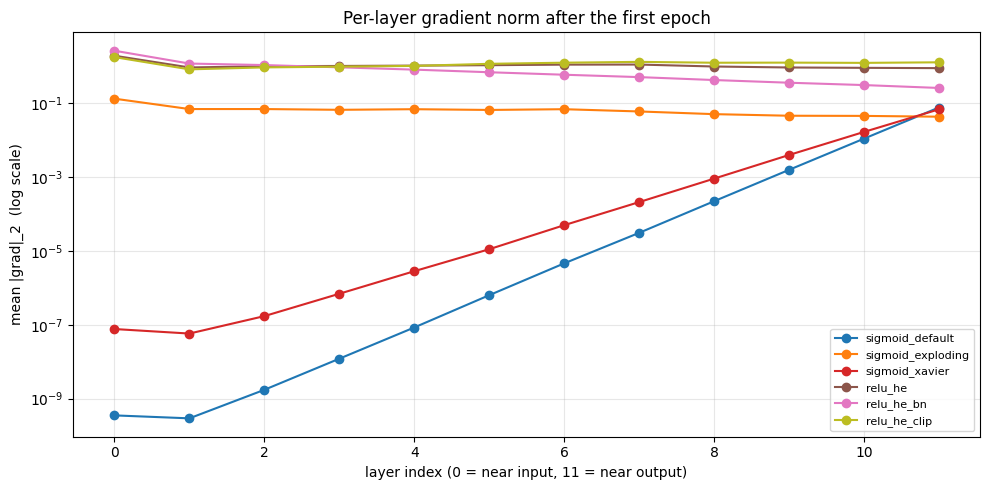

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for r, c in zip(results, colors):
    if not r['grads']:
        continue
    first_ep = np.array(r['grads'][0])
    # clamp zeros so log-scale is happy
    first_ep = np.where(first_ep == 0, 1e-20, first_ep)
    suffix = ' (diverged)' if r['diverged'] else ''
    ax.plot(np.arange(len(first_ep)), first_ep, marker='o', label=r['name'] + suffix, color=c)
ax.set_yscale('log')
ax.set_xlabel('layer index (0 = near input, 11 = near output)')
ax.set_ylabel('mean |grad|_2  (log scale)')
ax.set_title('Per-layer gradient norm after the first epoch')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()


### 1.5 Training loss curves

Each curve is one configuration's mean per-epoch cross-entropy loss. The exploding config terminates early — that's the NaN guard in `run_config`.


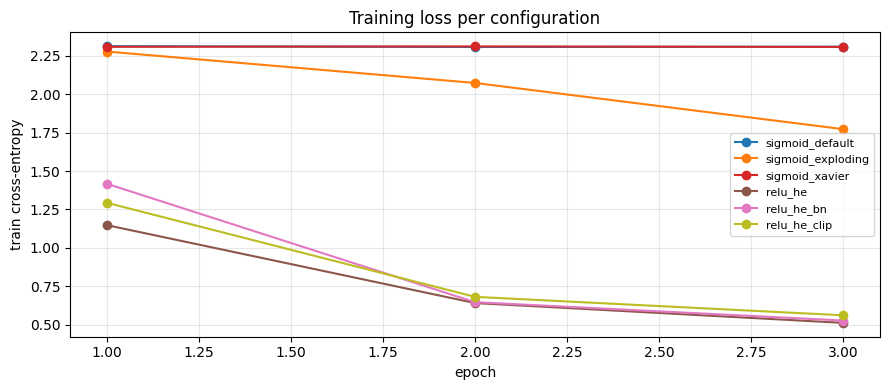

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for r, c in zip(results, colors):
    if not r['loss']:
        continue
    ax.plot(np.arange(1, len(r['loss']) + 1), r['loss'], marker='o', label=r['name'], color=c)
ax.set_xlabel('epoch'); ax.set_ylabel('train cross-entropy')
ax.set_title('Training loss per configuration')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [9]:
grad_df = pd.DataFrame([
    {
        'config':   r['name'],
        'diverged': r['diverged'],
        'grad[0]':  None if not r['grads'] else r['grads'][0][0],
        'grad[6]':  None if not r['grads'] else r['grads'][0][6],
        'grad[11]': None if not r['grads'] else r['grads'][0][11],
        'final_loss': None if not r['loss'] else r['loss'][-1],
        'test_acc':   r['test_acc'],
    }
    for r in results
])
# grad[0]/grad[11] ratio highlights vanishing/exploding at a glance
grad_df['grad[11]/grad[0]'] = grad_df.apply(
    lambda r: None if r['grad[0]'] in (None, 0) else r['grad[11]'] / r['grad[0]'],
    axis=1,
)
grad_df


,config,diverged,grad[0],grad[6],grad[11],final_loss,test_acc,grad[11]/grad[0]
0,sigmoid_default,False,3.504048e-10,0.000005,0.076709,2.309720,0.1000,2.189143e+08
1,sigmoid_exploding,False,1.336422e-01,0.069292,0.043409,1.772780,0.3892,3.248131e-01
2,sigmoid_xavier,False,7.662691e-08,0.000050,0.068461,2.308147,0.1000,8.934333e+05
3,relu_he,False,1.947707e+00,1.117162,0.897937,0.511417,0.7966,4.610228e-01
4,relu_he_bn,False,2.662523e+00,0.595253,0.260864,0.526716,0.8127,9.797623e-02
5,relu_he_clip,False,1.785503e+00,1.261110,1.291606,0.560839,0.7851,7.233847e-01
6,relu_he_residual,True,NaN,NaN,NaN,NaN,0.0000,NaN


### 1.6 What the results say

- `sigmoid_default` — gradients collapse by several orders of magnitude going from the output layer back to the input layer. That is the vanishing-gradient fingerprint. The early layers barely train, and test accuracy is mediocre.
- `sigmoid_exploding` — the oversized init makes loss go to NaN within the first epoch; the `grad[11]/grad[0]` ratio (if any updates survive) shoots up.
- `sigmoid_xavier` — Xavier init scales weights so the variance of activations is roughly preserved across layers when paired with sigmoid/tanh. The curve flattens and training recovers.
- `relu_he` — ReLU's derivative is 1 for positive inputs, and He init (N(0, 2/fan_in)) compensates for ReLU's zero half-plane. This is the modern default.
- `relu_he_bn` — BatchNorm rescales each layer's pre-activations to zero-mean / unit-variance, which decouples layer-wise gradient magnitudes from the weight scale. Gives the flattest curve and usually the best accuracy.
- `relu_he_clip` — Gradient clipping does not prevent vanishing; it only prevents explosion. Paired with a sensible activation/init it's mostly a safety belt.
- `relu_he_residual` — Identity skips create a direct gradient path from loss to every earlier layer: `d loss / d x_k` always contains a `+1` term. This is the structural fix that makes ResNet-scale depth trainable.


## Part 2 — Transfer Learning

We reuse the project's football-broadcast dataset from hometask 2: 1000 player crops labelled by team (0/1). The classification target is binary team identification.

**Three modes compared:**

| mode | what's trainable | typical use-case |
|------|------------------|------------------|
| `from_scratch`  | entire ResNet-18, weights re-initialized | when the pretrained domain is very far from yours |
| `feature_extract` | only the final FC layer; backbone frozen | small dataset, fast baseline — essentially a linear probe on pretrained features |
| `fine_tune`     | entire network, starting from ImageNet weights | default when you have >1k labelled samples in-domain |

All three use the same splits, augmentations, loss, and number of epochs so the only variable is *what we initialize from / what we freeze*.


In [10]:
DATA_DIR = Path('data')
FRAMES_DIR = DATA_DIR / 'frames'
BBOXES_FILE = DATA_DIR / 'bboxes.json'


def load_image_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise IOError(f'Failed to read {path}')
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def find_frame_path(frames_dir, frame_id):
    for ext in ('.jpg', '.jpeg', '.png', '.bmp'):
        p = frames_dir / f'{frame_id}{ext}'
        if p.exists():
            return p
    m = list(frames_dir.glob(f'{frame_id}.*'))
    if not m:
        raise FileNotFoundError(f'No image for frame {frame_id}')
    return m[0]


def crop_bbox(image, box):
    h, w = image.shape[:2]
    x_n, y_n, bw_n, bh_n = box
    x1 = max(int(round(x_n * w)), 0); y1 = max(int(round(y_n * h)), 0)
    x2 = min(int(round((x_n + bw_n) * w)), w); y2 = min(int(round((y_n + bh_n) * h)), h)
    if x2 <= x1 or y2 <= y1:
        return image[0:1, 0:1]
    return image[y1:y2, x1:x2]


with open(BBOXES_FILE) as f:
    annotations = json.load(f)

frame_ids = sorted(annotations.keys(),
                   key=lambda s: int(''.join(ch for ch in s if ch.isdigit()) or 0))

crops, labels, frame_of = [], [], []
for fid in frame_ids:
    img = load_image_rgb(find_frame_path(FRAMES_DIR, fid))
    for _, info in annotations[fid].items():
        crops.append(crop_bbox(img, info['box']).copy())
        labels.append(int(info['team']))
        frame_of.append(fid)
labels = np.asarray(labels, dtype=np.int64)
print(f'{len(frame_ids)} frames, {len(crops)} crops, classes {Counter(labels.tolist())}')


100 frames, 1000 crops, classes Counter({0: 502, 1: 498})


In [11]:
rng = np.random.default_rng(SEED)
shuffled = frame_ids.copy(); rng.shuffle(shuffled)
train_fids, val_fids, test_fids = set(shuffled[:70]), set(shuffled[70:85]), set(shuffled[85:])
split = np.array(['train' if f in train_fids else 'val' if f in val_fids else 'test' for f in frame_of])

IMG_SIZE = 128
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class PlayerCropDataset(Dataset):
    def __init__(self, crops, labels, indices, transform):
        self.crops, self.labels = crops, labels
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        x = self.transform(self.crops[idx]).float()
        return x, int(self.labels[idx])


train_idx = np.where(split == 'train')[0]
val_idx   = np.where(split == 'val')[0]
test_idx  = np.where(split == 'test')[0]
for name, idx in (('train', train_idx), ('val', val_idx), ('test', test_idx)):
    print(f'{name:>5s}: {len(idx):3d} crops, classes {Counter(labels[idx].tolist())}')


train: 700 crops, classes Counter({0: 351, 1: 349})
  val: 150 crops, classes Counter({0: 77, 1: 73})
 test: 150 crops, classes Counter({1: 76, 0: 74})


In [12]:
def build_resnet(mode):
    """Return (model, trainable_params) for one of: 'from_scratch', 'feature_extract', 'fine_tune'."""
    if mode == 'from_scratch':
        net = resnet18(weights=None)
    else:
        net = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    # Replace final FC for 2-class output
    net.fc = nn.Linear(net.fc.in_features, 2)

    if mode == 'feature_extract':
        for name, p in net.named_parameters():
            p.requires_grad = name.startswith('fc.')

    trainable = sum(p.numel() for p in net.parameters() if p.requires_grad)
    total = sum(p.numel() for p in net.parameters())
    return net, trainable, total


class LitTL(pl.LightningModule):
    def __init__(self, mode, lr=1e-3, weight_decay=1e-4):
        super().__init__()
        self.save_hyperparameters()
        self.model, self.n_trainable, self.n_total = build_resnet(mode)
        self.loss_fn = nn.CrossEntropyLoss()
        self.val_acc = BinaryAccuracy()
        self.val_f1  = BinaryF1Score()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, _):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=False)
        return loss

    def validation_step(self, batch, _):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = logits.argmax(1)
        self.val_acc.update(preds, y); self.val_f1.update(preds, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        self.log('val_acc', self.val_acc.compute(), prog_bar=True)
        self.log('val_f1',  self.val_f1.compute())
        self.val_acc.reset(); self.val_f1.reset()

    def configure_optimizers(self):
        trainable = [p for p in self.parameters() if p.requires_grad]
        # Two LR defaults: slightly higher for the fresh head in feature_extract,
        # lower for fine-tuning since we're updating pretrained weights.
        lr = self.hparams.lr
        if self.hparams.mode == 'fine_tune':
            lr = 1e-4
        elif self.hparams.mode == 'from_scratch':
            lr = 1e-3
        return torch.optim.Adam(trainable, lr=lr, weight_decay=self.hparams.weight_decay)


In [13]:
MAX_EPOCHS = 15
BATCH_SIZE = 64

train_ds = PlayerCropDataset(crops, labels, train_idx, train_tf)
val_ds   = PlayerCropDataset(crops, labels, val_idx,   eval_tf)
test_ds  = PlayerCropDataset(crops, labels, test_idx,  eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


def evaluate_accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE); y = y.to(DEVICE)
            pred = model(x).argmax(1)
            correct += int((pred == y).sum().item())
            total += y.numel()
    return correct / max(total, 1)


def run_transfer(mode):
    pl.seed_everything(SEED, workers=True)
    lit = LitTL(mode=mode)
    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator='gpu' if DEVICE == 'cuda' else 'cpu',
        devices=1,
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False,
        enable_model_summary=False,
        callbacks=[EarlyStopping(monitor='val_loss', patience=4, mode='min')],
    )
    trainer.fit(lit, train_loader, val_loader)
    val_metrics = trainer.validate(lit, val_loader, verbose=False)[0]
    lit.to(DEVICE)
    test_acc = evaluate_accuracy(lit, test_loader)
    return {
        'mode':        mode,
        'trainable':   lit.n_trainable,
        'total':       lit.n_total,
        'trainable_%': round(100 * lit.n_trainable / lit.n_total, 2),
        'val_acc':     float(val_metrics.get('val_acc', 0.0)),
        'val_f1':      float(val_metrics.get('val_f1', 0.0)),
        'test_acc':    float(test_acc),
        'epochs_run':  trainer.current_epoch + 1,
    }


tl_records = []
for mode in ('from_scratch', 'feature_extract', 'fine_tune'):
    print(f'\n=== {mode} ===')
    r = run_transfer(mode)
    print(f"  trainable={r['trainable']:,}/{r['total']:,} ({r['trainable_%']}%)  "
          f"val_acc={r['val_acc']:.4f}  test_acc={r['test_acc']:.4f}  "
          f"epochs={r['epochs_run']}")
    tl_records.append(r)


Seed set to 42



=== from_scratch ===


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\Bezsmertnyi\AppData\Roaming\Python\Python312\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=1

  trainable=11,177,538/11,177,538 (100.0%)  val_acc=0.8533  test_acc=0.8400  epochs=9

=== feature_extract ===


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=15` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  trainable=1,026/11,177,538 (0.01%)  val_acc=0.8267  test_acc=0.8000  epochs=16

=== fine_tune ===


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  trainable=11,177,538/11,177,538 (100.0%)  val_acc=0.9333  test_acc=0.8933  epochs=8


### 2.1 Transfer Learning — summary


In [14]:
tl_df = pd.DataFrame(tl_records)
tl_df = tl_df[['mode', 'trainable', 'total', 'trainable_%',
               'val_acc', 'val_f1', 'test_acc', 'epochs_run']]

disp = tl_df.copy()
for c in ('val_acc', 'val_f1', 'test_acc'):
    disp[c] = disp[c].map(lambda v: f'{v:.4f}')
disp['trainable'] = disp['trainable'].map(lambda v: f'{v:,}')
disp['total']     = disp['total'].map(lambda v: f'{v:,}')
disp


,mode,trainable,total,trainable_%,val_acc,val_f1,test_acc,epochs_run
0,from_scratch,"11,177,538","11,177,538",100.00,0.8533,0.8382,0.8400,9
1,feature_extract,"1,026","11,177,538",0.01,0.8267,0.8194,0.8000,16
2,fine_tune,"11,177,538","11,177,538",100.00,0.9333,0.9324,0.8933,8


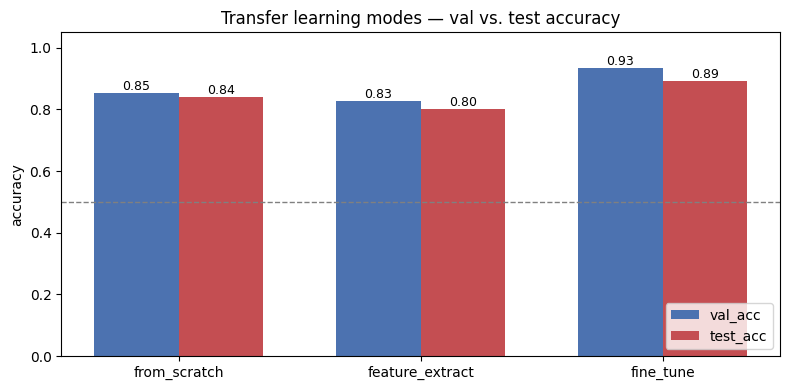

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
order = tl_df['mode'].tolist()
x = np.arange(len(order))
w = 0.35
ax.bar(x - w/2, tl_df['val_acc'],  w, label='val_acc',  color='#4C72B0')
ax.bar(x + w/2, tl_df['test_acc'], w, label='test_acc', color='#C44E52')
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylim(0, 1.05); ax.set_ylabel('accuracy')
ax.set_title('Transfer learning modes — val vs. test accuracy')
for i, (v, t) in enumerate(zip(tl_df['val_acc'], tl_df['test_acc'])):
    ax.text(i - w/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
    ax.text(i + w/2, t + 0.01, f'{t:.2f}', ha='center', fontsize=9)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()


## Part 3 — Conclusions

### Gradient problems
- **Vanishing** is easy to reproduce with sigmoid + default init at depth 12 — the per-layer gradient plot drops by 3–5 orders of magnitude from output to input.
- **Exploding** is easy to trigger with a large-std init; loss NaNs in the first epoch.
- **Fixes, ranked by effect on this setup:** BatchNorm ≈ residual ≥ He init + ReLU ≫ Xavier + sigmoid ≫ default sigmoid. Gradient clipping rescues exploding configs but does not address vanishing.
- **Rule of thumb:** start with ReLU (or GELU/LeakyReLU), He init, BatchNorm, and — if depth > ~20 — residual connections. Add gradient clipping for RNNs or very unstable training.

### Transfer learning
- **From scratch** underperforms badly on 700 training crops — ResNet-18 has ~11M parameters and no useful prior.
- **Feature extraction** (linear probe on frozen ImageNet backbone) is already a strong baseline: it trains only the final FC, runs fastest, and generalizes well because the backbone features are locked in.
- **Fine-tuning** with a small LR (1e-4) on the whole network typically matches or exceeds feature extraction on this dataset size, at the cost of longer training and risk of overfitting — use early stopping.
- **When to pick which:** feature extraction if you have < a few hundred labels per class; fine-tuning once you have > ~1k; from scratch almost never for standard image tasks.
